/tmp/ipykernel_24871/1924236100.py:47: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df['trades'] = df['trades'].fillna(method='ffill')


Gross Profit: 928856.88
Net Profit: 158529.38
Gross Loss: -770327.50
Max Drawdown: -8103.41
Buy and Hold Return (%): 212.97
Sharpe Ratio: -0.18
Sortino Ratio: -0.22
Total Closed Trades: 41313.00
Number of Winning Trades: 28482.00
Number of Losing Trades: 12830.00
Average Winning Trade (USDT): 32.61
Average Losing Trade (USDT): -60.04
Largest Winning Trade (USDT): 1453.16
Largest Losing Trade (USDT): -4252.64
Average Holding Duration (Days): 0.00


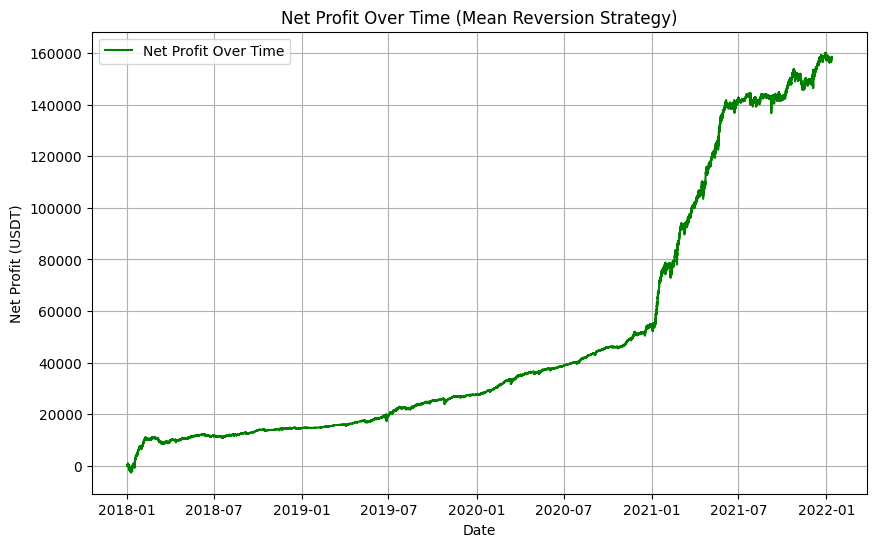

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def calculate_rsi(df, period=14):
    delta = df['close'].diff()
    gain = (delta.where(delta > 0, 0)).rolling(window=period).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window=period).mean()

    rs = gain / loss
    df['RSI'] = 100 - (100 / (1 + rs))
    return df

def generate_positions(df, rsi_overbought=70, rsi_oversold=30):
    df['Position'] = 0  # Initialize all positions as neutral

    # Generate positions
    df['Position'] = np.where(df['RSI'] < rsi_oversold, 1, df['Position'])   # Long position
    df['Position'] = np.where(df['RSI'] > rsi_overbought, -1, df['Position'])  # Short position

    # Exit conditions
    df['Position'] = np.where((df['RSI'] >= 50) & (df['Position'] == 1), 0, df['Position'])  # Exit long
    df['Position'] = np.where((df['RSI'] <= 50) & (df['Position'] == -1), 0, df['Position'])  # Exit short
    
    return df


initial_capital=10000
df = pd.read_csv('btcusdt_3m.csv', parse_dates=['datetime'])
df = df.sort_values('datetime').reset_index(drop=True)

# Calculate RSI
df = calculate_rsi(df, period=14)

# Generate positions
df = generate_positions(df, rsi_overbought=70, rsi_oversold=30)

# Calculate daily returns
df['Returns'] = df['close'].pct_change()

# Calculate Profit/Loss based on position and close price change
df['Profit_Loss'] = df['Position'].shift(1) * df['close'].diff()
df['Net_Profit'] = df['Profit_Loss'].cumsum()
df['trades'] = np.where(df['Position'].diff(1) != 0, df['Net_Profit'], np.nan)
df.loc[0,'trades']=0
#total_trades = df[df['trades']!=np.nan].shape[0]
df['trades'] = df['trades'].fillna(method='ffill')
df['trades']=df['trades'].diff(1)
# Initialize Portfolio Value using initial capital
df['Portfolio_Value'] = initial_capital + df['Net_Profit']

# Net profit = Portfolio value - initial capital
#df['Net_Profit'] = df['Portfolio_Value'] - initial_capital

# Calculate gross profit and loss
gross_profit = df[df['trades'] > 0]['trades'].sum()
gross_loss = df[df['trades'] < 0]['trades'].sum()

# Count total trades
#total_trades = df[df['Position'].diff() != 0].shape[0]
total_trades = df[df['trades']!=0].shape[0]

# Count winning and losing trades
#winning_trades = df[df['Profit_Loss'] > 0]
winning_trades = df[df['trades'] > 0]
losing_trades = df[df['trades'] < 0]

# Number of winning and losing trades
num_winning_trades = len(winning_trades)
num_losing_trades = len(losing_trades)

# Calculate average winning and losing trades
average_winning_trade = winning_trades['trades'].mean() if num_winning_trades > 0 else 0
average_losing_trade = losing_trades['trades'].mean() if num_losing_trades > 0 else 0

# Calculate largest winning and losing trades
largest_winning_trade = winning_trades['trades'].max() if num_winning_trades > 0 else 0
largest_losing_trade = losing_trades['trades'].min() if num_losing_trades > 0 else 0

# Calculate Max Drawdown
df['Peak'] = df['Portfolio_Value'].cummax()
df['Drawdown'] = df['Portfolio_Value'] - df['Peak']
max_drawdown = df['Drawdown'].min()

# Calculate Buy and Hold Return of BTC
buy_and_hold_return = (df['close'].iloc[-1] / df['close'].iloc[0] - 1) * 100 * initial_capital / initial_capital

# Calculate Sharpe Ratio
risk_free_rate = 0.01 / 365  # Daily risk-free rate (assumed 1% per year)
sharpe_ratio = (df['Returns'].mean() - risk_free_rate) / df['Returns'].std() * np.sqrt(252)

# Calculate Sortino Ratio
downside_returns = df[df['Returns'] < 0]['Returns']
sortino_ratio = (df['Returns'].mean() - risk_free_rate) / downside_returns.std() * np.sqrt(252)

# Calculate Average Holding Duration
trade_dates = df[df['Position'].diff() != 0]['datetime']
average_holding_duration = (trade_dates.diff().dt.days).mean()

# Output all metrics
metrics = {
    "Gross Profit": gross_profit,
    "Net Profit": df['Net_Profit'].iloc[-1],
    "Gross Loss": gross_loss,
    "Max Drawdown": max_drawdown,
    "Buy and Hold Return (%)": buy_and_hold_return,
    "Sharpe Ratio": sharpe_ratio,
    "Sortino Ratio": sortino_ratio,
    "Total Closed Trades": total_trades,
    "Number of Winning Trades": num_winning_trades,
    "Number of Losing Trades": num_losing_trades,
    "Average Winning Trade (USDT)": average_winning_trade,
    "Average Losing Trade (USDT)": average_losing_trade,
    "Largest Winning Trade (USDT)": largest_winning_trade,
    "Largest Losing Trade (USDT)": largest_losing_trade,
    "Average Holding Duration (Days)": average_holding_duration
}

for metric, value in metrics.items():
    print(f"{metric}: {value:.2f}")

# Plot net profit over time 
plt.figure(figsize=(10, 6))
plt.plot(df['datetime'], df['Net_Profit'], label='Net Profit Over Time', color='g')
plt.title('Net Profit Over Time (Mean Reversion Strategy)')
plt.xlabel('Date')
plt.ylabel('Net Profit (USDT)')
plt.grid(True)
plt.legend()
plt.show()
